In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

In [5]:
#red dataset
df_raw = pd.read_csv('../data/gas_price_2526.csv')

#check columns
print("Columns found in CSV:", df_raw.columns.tolist())

#convert date to datetime object
date_col = [col for col in df_raw.columns if 'date' in col.lower()][0]
price_col = [col for col in df_raw.columns if 'price' in col.lower()][0]
df_raw[date_col] = pd.to_datetime(df_raw[date_col])

#set index
df = df_raw.set_index(date_col).sort_index()

df = df[[price_col]].rename(columns={price_col: 'daily price'})

print(df.head())

Columns found in CSV: ['date', 'daily price']
            daily price
date                   
2025-01-19        39.85
2025-01-20        37.21
2025-01-21        37.33
2025-01-22        37.85
2025-01-23        35.70


C:\Users\sagal\AppData\Local\Temp\ipykernel_24648\2157977167.py:10: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_raw[date_col] = pd.to_datetime(df_raw[date_col])


In [6]:
# 2. Feature Engineering: Create 7 days of historical lags for ML training
ml_df = df[['daily price']].copy()
for i in range(1, 8):
    ml_df[f'lag_{i}'] = ml_df['daily price'].shift(i)

# Add a 7-day rolling average to capture the immediate past trend momentum
ml_df['rolling_mean_7'] = ml_df['daily price'].shift(1).rolling(window=7).mean()

# Drop the first 7 rows because shifting creates NaN values
ml_df.dropna(inplace=True)

# 3. Separate into Features (X) and Target (y)
X = ml_df.drop(columns=['daily price'])
y = ml_df['daily price']



In [7]:
# 4. Time-Series Split (Hold back the final 30 days to evaluate all ML models fairly)
train_size = len(ml_df) - 30
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# 5. Train the Linear Regression Benchmark
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 6. Generate Validation Predictions
lr_preds = lr_model.predict(X_test)

# 7. Calculate Performance Metrics
lr_mae = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_mape = mean_absolute_percentage_error(y_test, lr_preds) * 100

print(f"=== Linear Regression ML Baseline ===")
print(f"MAE:  {lr_mae:.4f}")
print(f"RMSE: {lr_rmse:.4f}")
print(f"MAPE: {lr_mape:.2f}%")

=== Linear Regression ML Baseline ===
MAE:  0.8577
RMSE: 1.0837
MAPE: 1.05%


In [8]:
# Check which features the model relies on most
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
})
print("=== Linear Regression Feature Importance ===")
print(coefficients.to_string(index=False))
print(f"Intercept: {lr_model.intercept_:.4f}")

=== Linear Regression Feature Importance ===
       Feature  Coefficient
         lag_1     1.703004
         lag_2    -1.421543
         lag_3     1.274391
         lag_4    -1.050458
         lag_5     0.674295
         lag_6    -0.459102
         lag_7     0.152099
rolling_mean_7     0.124669
Intercept: 0.2220


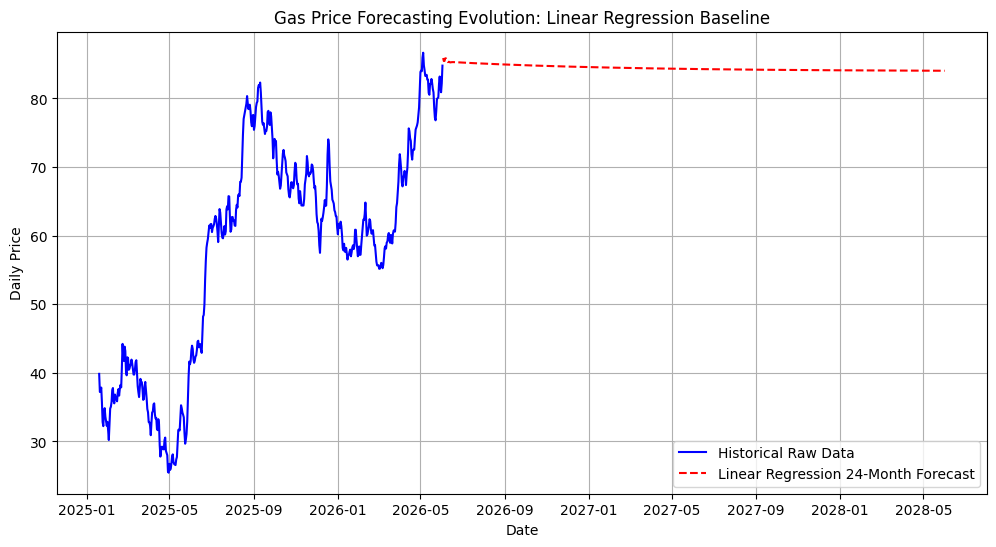

In [9]:
# ==========================================
# RECURSIVE 24-MONTH FUTURE FORECAST
# ==========================================

# 1. Define the forecast horizon (24 months = approx 730 days)
horizon = 730

# 2. Get the last 7 days of actual raw data to kickstart our loop
# We use the very end of our original 'df' to start forecasting into the future
last_known_sequence = df['daily price'].iloc[-7:].tolist()

future_forecasts = []

# 3. Run the recursive forecasting loop
for step in range(horizon):
    # Prepare the input features exactly how the model expects them:
    # Lags are ordered from lag_1 (most recent) to lag_7 (oldest)
    lags = list(reversed(last_known_sequence[-7:]))
    
    # Calculate the 7-day rolling mean of these lags
    rolling_mean = np.mean(lags)
    
    # Combine them into a single row of features [lag_1, ..., lag_7, rolling_mean_7]
    features = lags + [rolling_mean]
    X_input = pd.DataFrame([features], columns=X.columns)
    
    # Predict the next step
    next_pred = lr_model.predict(X_input)[0]
    
    # Store the prediction
    future_forecasts.append(next_pred)
    
    # Append the prediction to our sequence so it becomes 'lag_1' for the next step
    last_known_sequence.append(next_pred)

# 4. Create a Datetime Index for the future forecast
future_dates = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), periods=horizon, freq='D')
forecast_series = pd.Series(future_forecasts, index=future_dates)

# ==========================================
# PLOT THE 24-MONTH FUTURE FORECAST
# ==========================================
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['daily price'], label='Historical Raw Data', color='blue')
plt.plot(forecast_series.index, forecast_series, label='Linear Regression 24-Month Forecast', color='red', linestyle='--')
plt.title('Gas Price Forecasting Evolution: Linear Regression Baseline')
plt.xlabel('Date')
plt.ylabel('Daily Price')
plt.legend()
plt.grid(True)
plt.show()

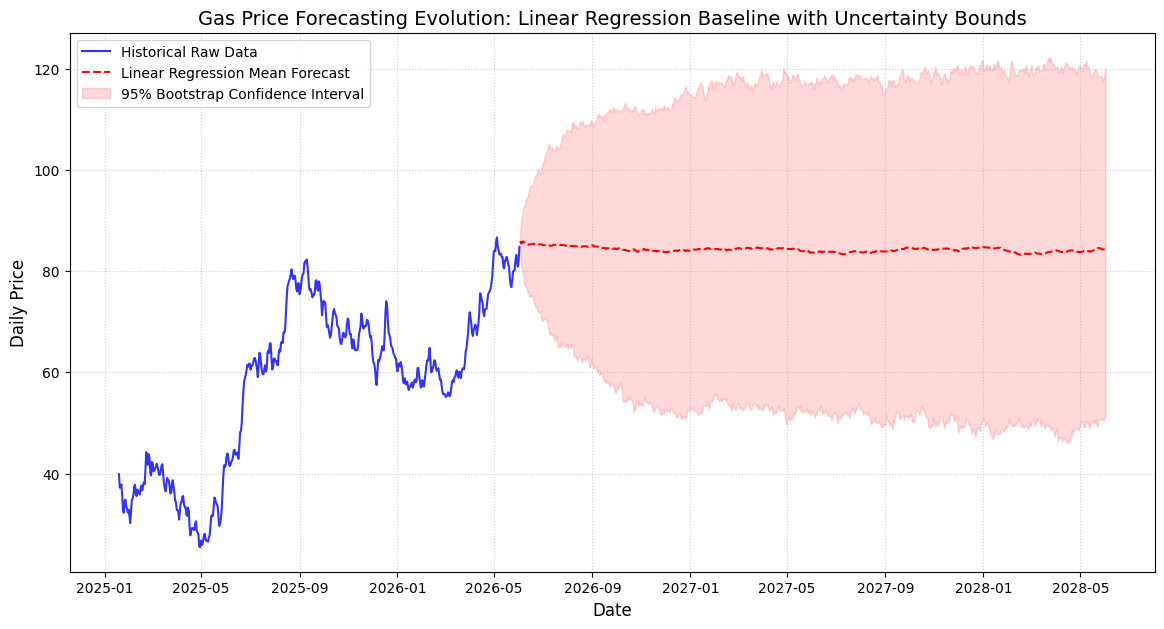

In [10]:
# =====================================================================
# LINEAR REGRESSION FORECAST WITH BOOTSTRAPPED CONFIDENCE INTERVALS
# =====================================================================

# 1. Calculate historical training residuals (errors)
train_preds = lr_model.predict(X_train)
residuals = y_train - train_preds

# 2. Set up simulation parameters
horizon = 730
n_simulations = 500
np.random.seed(42)  # For reproducible paths

# Array to hold all simulated paths: shape (730 days, 500 simulations)
all_simulated_paths = np.zeros((horizon, n_simulations))

# 3. Run the bootstrap simulation loop
for sim in range(n_simulations):
    # Grab the last 7 days of known actual data to kickstart this specific path
    last_sequence = df['daily price'].iloc[-7:].tolist()
    
    for step in range(horizon):
        # Prepare features exactly like training [lag_1, ..., lag_7, rolling_mean]
        lags = list(reversed(last_sequence[-7:]))
        rolling_mean = np.mean(lags)
        features = lags + [rolling_mean]
        X_input = pd.DataFrame([features], columns=X.columns)
        
        # Get the baseline point prediction
        point_pred = lr_model.predict(X_input)[0]
        
        # Randomly sample an error from our historical training residuals
        random_error = np.random.choice(residuals)
        
        # The simulated price is the point prediction + the random historical shock
        simulated_price = point_pred + random_error
        
        # Append to our sequence so it feeds into the next step's lags
        last_sequence.append(simulated_price)
        all_simulated_paths[step, sim] = simulated_price

# 4. Calculate percentiles for the 95% Confidence Interval across the 500 paths
forecast_point = np.mean(all_simulated_paths, axis=1)
lower_bound = np.percentile(all_simulated_paths, 2.5, axis=1)
upper_bound = np.percentile(all_simulated_paths, 97.5, axis=1)

# 5. Build Datetime series objects for plotting
future_dates = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), periods=horizon, freq='D')
forecast_series = pd.Series(forecast_point, index=future_dates)
lower_series = pd.Series(lower_bound, index=future_dates)
upper_series = pd.Series(upper_bound, index=future_dates)

# =====================================================================
# VISUALIZE THE EVOLUTIONARY BASELINE PLOT
# =====================================================================
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['daily price'], label='Historical Raw Data', color='blue', alpha=0.8)
plt.plot(forecast_series.index, forecast_series, label='Linear Regression Mean Forecast', color='red', linestyle='--')
plt.fill_between(future_dates, lower_series, upper_series, color='red', alpha=0.15, label='95% Bootstrap Confidence Interval')

plt.title('Gas Price Forecasting Evolution: Linear Regression Baseline with Uncertainty Bounds', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily Price', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()